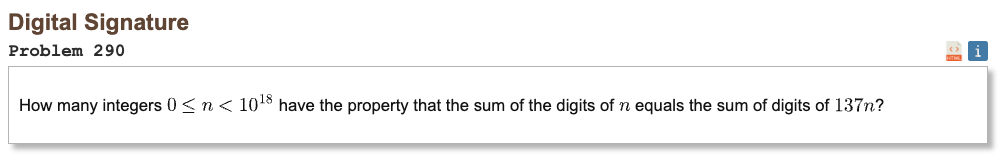

## Initial approach

* Write the number as an 18-digit number, allowing leading zeros.
* Multiply it by 137 from right to left, exactly as in ordinary handwritten multiplication, while keeping track of the carry at each step.
* At every step, the current digit and the current carry determine one new output digit and also the next carry.
* The condition in the problem can then be rewritten as a balance between digit sums, updating that balance after each step by comparing the new digit with the original one.
* After all 18 digits have been processed, a small carry still remains, and the digit sum of that carry must also be included in the balance.
* This makes it natural to use dynamic programming based on three things: the current position, the carry, and the current difference in digit sums.
* The carry never becomes large, so the total number of possible states stays small and the method runs quickly.
* At the end, count all cases where the running balance becomes zero after also including the digit sum of the final carry.

In [1]:
from collections import defaultdict

def digit_sum(x):
    return sum(int(ch) for ch in str(x))

def solve():
    dp = {(0, 0): 1}

    for _ in range(18):
        new_dp = defaultdict(int)
        for (carry, diff), count in dp.items():
            for d in range(10):
                t = 137 * d + carry
                out_digit = t % 10
                new_carry = t // 10
                new_diff = diff + out_digit - d
                new_dp[(new_carry, new_diff)] += count
        dp = new_dp

    result = 0
    for (carry, diff), count in dp.items():
        if diff + digit_sum(carry) == 0:
            result += count

    return result

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 20444710234716473
CPU times: user 428 ms, sys: 7.21 ms, total: 435 ms
Wall time: 435 ms
